In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
%matplotlib inline
from graphviz import Digraph
import random

In [ ]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._op = _op
    self.label = label
    self._backward = lambda:None
    self._prev = set(_children)

  # This is use to represent the output properly
  def __repr__(self):
    return f"Value(data={self.data})"

  # This is for add rule and I used __add__ to make it possible to use "+"
  # z = x + y; dz/dx = 1 + 0 and dz/dy = 0 + 1
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

# This is add rule calculus derivative
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  # reverse addition
  def __radd__(self, other):
    return self + other

  # This is for mul rule and I used __mul__ to make it possible to use "*"
  # z = x*y; dz/dx = y, dz/dy = x
  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

  # This is Mul Calculus derivative
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  # reversed mul
  def __rmul__(self, other):
    return self * other

  # negative
  def __neg__(self):
    return self * -1

  # substraction
  def __sub__(self, other):
    return self + (-other)

  # division
  def __truediv__(self, other):
    return self * other**-1

  # this is for power rule
  # z = X^n , dz/dx = n * X^n-1
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
 # This is for Tanh rule
 # tanh derivative is
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out
# This is for relu
  def relu(self):
    out = Value(0 if self.data < 0 else self.data, (self, ), 'ReLU')

    def _backward():
      self.grad += (out.data > 0) * out.grad
    out._backward = _backward
    return out
# exponential
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
      build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()




```
# Test
```


In [ ]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')

In [ ]:
# Testing with formular of a straight line y = mx+c
d = a * b + c
d

Value(data=4.0)

In [ ]:
# Testing with E = Mc^2 (Einstein Physics)
j = Value(20, label='j')
k = Value(3e32, label = 'k')
L = j * k ** 2
L

Value(data=1.8e+66)

In [ ]:
def trace(root):
  # build a set of all node and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str (id(n))
  # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

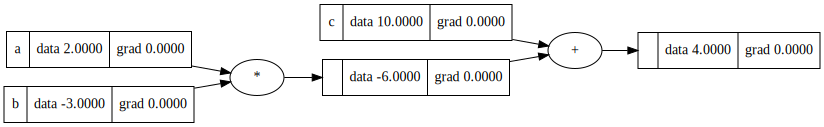

In [ ]:
draw_dot(d)

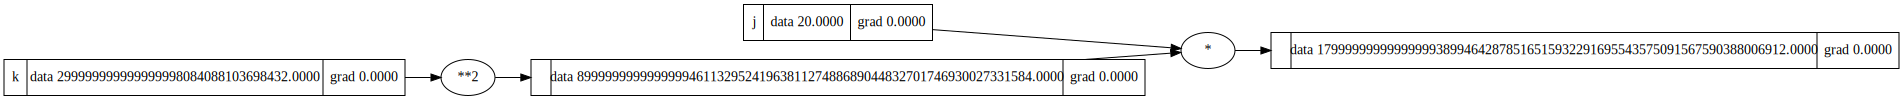

In [ ]:
draw_dot(L)

### Demonstrating Biology Dendrite Neuron with Mathematics

In [ ]:
# input x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weight
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(3.1427, label='b') # see what I did there PI lol

# x1w1 + x2w2 * b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.relu(); o.label = 'o'
o.backward()

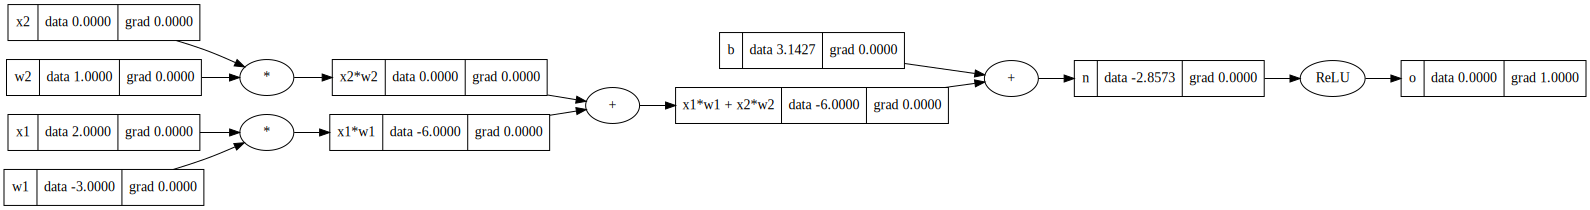

In [ ]:
draw_dot(o)

### Creating Neuron Function

In [ ]:
class Neuron:
  def __init__(self, nin): #nin means number of input
    self.w =[Value(random.uniform(-1,1)) for _ in range(nin)] # weight
    self.b = Value(random.uniform(-1,1)) # bias

  def __call__(self, x):
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh() # you can change the activation function to relu or whichever one
    return out

  def parameters(self):
    return self.w + [self.b]
class Layer:
  def __init__(self, nin, nout): # nout means number of output
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
  # Multi Layer Perceptron
class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  def  parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.31834451656284485)

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [ ]:
for k in range(10):
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 2.9779815326302654
1 2.9779815326302654
2 2.9779815326302654
3 2.9779815326302654
4 2.9779815326302654
5 2.9779815326302654
6 2.9779815326302654
7 2.9779815326302654
8 2.9779815326302654
9 2.9779815326302654


In [ ]:
ypred

[Value(data=0.31834451656284485),
 Value(data=0.37760480759198106),
 Value(data=-0.4993256681713941),
 Value(data=0.3959656118417065)]